In [77]:
import pandas as pd
import numpy as np
import sys
import os
import gc

import unicodedata
import re

import seaborn as sns
import matplotlib.pyplot as plt

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')

Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2


In [78]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path_main = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [79]:
def save_data_frame(df: pd.DataFrame, path_dataset: str):
  df.to_csv(path_dataset, index=True)

In [80]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [81]:
def limpar_nomes(coluna):
    # Converte para minúsculo
    coluna = coluna.lower()
    # Remove acentos e caracteres especiais
    coluna = unicodedata.normalize('NFKD', coluna).encode('ascii', 'ignore').decode('utf-8')
    # Substitui espaços e caracteres não alfanuméricos por underline
    coluna = re.sub(r'[^a-z0-9]+', '_', coluna)
    # Remove underlines extras no início ou fim
    return coluna.strip('_')

## Import dengue

In [82]:
path_dengue_rj = f'{path_main}/dengue_rj_2020_2026_analise.csv'
df_dengue = get_data_frame(path_dengue_rj)

In [83]:
df_dengue.index

RangeIndex(start=0, stop=92794, step=1)

In [84]:
df_dengue.rename(columns={'DT_SIN_PRI':'Data'}, inplace=True)

In [85]:
df_dengue['Data'] = pd.to_datetime(df_dengue['Data'])
df_dengue.set_index('Data', inplace=True)

In [86]:
df_dengue.index

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01',
               ...
               '2026-04-21', '2026-04-21', '2026-04-21', '2026-04-21',
               '2026-04-22', '2026-04-22', '2026-04-22', '2026-04-22',
               '2026-04-22', '2026-04-23'],
              dtype='datetime64[ns]', name='Data', length=92794, freq=None)

In [87]:
df_dengue.shape, df_dengue.columns

((92794, 35),
 Index(['CS_SEXO', 'CS_GESTANT', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA',
        'VOMITO', 'NAUSEA', 'DOR_RETRO', 'ARTRALGIA', 'ARTRITE', 'CONJUNTVIT',
        'PETEQUIA_N', 'LACO', 'DIABETES', 'HIPERTENSA', 'RENAL', 'HEMATOLOG',
        'HEPATOPAT', 'CLASSI_FIN', 'EVOLUCAO', 'IDADE', 'FAIXA_ETARIA', 'YEAR',
        'MONTH', 'DAY_WEEK', 'DAY_MONTH', 'DAY_MONTH_START', 'DAY_MONTH_END',
        'DAY_QUARTER_START', 'DAY_QUARTER_END', 'DAY_YEAR_START',
        'DAY_YEAR_END', 'CLASSIFICACAO', 'DESFECHO'],
       dtype='object'))

In [88]:
df_dengue.columns = [limpar_nomes(col) for col in df_dengue.columns]
df_dengue.shape, df_dengue.columns

((92794, 35),
 Index(['cs_sexo', 'cs_gestant', 'febre', 'mialgia', 'cefaleia', 'exantema',
        'vomito', 'nausea', 'dor_retro', 'artralgia', 'artrite', 'conjuntvit',
        'petequia_n', 'laco', 'diabetes', 'hipertensa', 'renal', 'hematolog',
        'hepatopat', 'classi_fin', 'evolucao', 'idade', 'faixa_etaria', 'year',
        'month', 'day_week', 'day_month', 'day_month_start', 'day_month_end',
        'day_quarter_start', 'day_quarter_end', 'day_year_start',
        'day_year_end', 'classificacao', 'desfecho'],
       dtype='object'))

In [89]:
df_dengue.isna().sum().sum()

np.int64(0)

## Import INMET

In [90]:
path_inmet_rj = f'{path_main}/inmet_2020_2026_analise.csv'
df_in = get_data_frame(path_inmet_rj)

In [91]:
df_in.index

RangeIndex(start=0, stop=219072, step=1)

In [92]:
df_in['Data'] = pd.to_datetime(df_in['Data'], errors='coerce')
df_in = df_in.sort_values('Data')
df_in.set_index('Data', inplace=True)

In [93]:
df_in.index

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01',
               ...
               '2026-03-31', '2026-03-31', '2026-03-31', '2026-03-31',
               '2026-03-31', '2026-03-31', '2026-03-31', '2026-03-31',
               '2026-03-31', '2026-03-31'],
              dtype='datetime64[ns]', name='Data', length=219072, freq=None)

In [94]:
df_in.columns

Index(['hora_utc', 'precipitacao_total_horario_mm',
       'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb',
       'pressao_atmosferica_max_na_hora_ant_aut_mb',
       'pressao_atmosferica_min_na_hora_ant_aut_mb', 'radiacao_global_kj_m2',
       'temperatura_do_ar_bulbo_seco_horaria_c',
       'temperatura_do_ponto_de_orvalho_c',
       'temperatura_maxima_na_hora_ant_aut_c',
       'temperatura_minima_na_hora_ant_aut_c',
       'temperatura_orvalho_max_na_hora_ant_aut_c',
       'temperatura_orvalho_min_na_hora_ant_aut_c',
       'umidade_rel_max_na_hora_ant_aut', 'umidade_rel_min_na_hora_ant_aut',
       'umidade_relativa_do_ar_horaria', 'vento_direcao_horaria_gr_gr',
       'vento_rajada_maxima_m_s', 'vento_velocidade_horaria_m_s', 'codigo',
       'estacao', 'YEAR', 'MONTH', 'DAY_WEEK', 'DAY_MONTH', 'DAY_MONTH_START',
       'DAY_MONTH_END', 'DAY_QUARTER_START', 'DAY_QUARTER_END',
       'DAY_YEAR_START', 'DAY_YEAR_END'],
      dtype='object')

In [95]:
df_in.isna().sum().sum()

np.int64(0)

# Join DataFrames

#### Etapa 1: O "Dataframe Mestre" (Nível Paciente + Clima)

In [96]:
# Preparação do INMET (Agregação Diária)
df_in_diario = df_in.groupby('Data').agg({
    'precipitacao_total_horario_mm': 'sum',    # Chuva acumulada no dia
    'temperatura_do_ar_bulbo_seco_horaria_c': 'mean', # Temperatura média
    'temperatura_maxima_na_hora_ant_aut_c': 'max',   # Pico de calor
    'temperatura_minima_na_hora_ant_aut_c': 'min',   # Mínima do dia
    'umidade_relativa_do_ar_horaria': 'mean',        # Umidade média
    'vento_velocidade_horaria_m_s': 'mean'           # Vento médio
}).rename(columns={
    'precipitacao_total_horario_mm': 'chuva_dia',
    'temperatura_do_ar_bulbo_seco_horaria_c': 'temp_media_dia',
    'temperatura_maxima_na_hora_ant_aut_c': 'temp_max_dia',
    'temperatura_minima_na_hora_ant_aut_c': 'temp_min_dia',
    'umidade_relativa_do_ar_horaria': 'umidade_dia'
})

In [97]:
# Garantir que os índices de data estejam normalizados (sem horas residuais)
df_dengue.index = pd.to_datetime(df_dengue.index).normalize()
df_in_diario.index = pd.to_datetime(df_in_diario.index).normalize()

In [98]:
# MERGE
# Usamos 'left' para garantir que nenhum paciente do SINAN seja jogado fora.
# O clima do dia será repetido para todos os pacientes daquela mesma data.
df_mestre = df_dengue.merge(df_in_diario, left_index=True, right_index=True, how='left')

In [99]:
# Verificação
print(f"Shape original SINAN: {df_dengue.shape}")
print(f"Shape Dataframe Mestre: {df_mestre.shape}")
print(f"Colunas disponíveis: {df_mestre.columns.tolist()}")

Shape original SINAN: (92794, 35)
Shape Dataframe Mestre: (92794, 41)
Colunas disponíveis: ['cs_sexo', 'cs_gestant', 'febre', 'mialgia', 'cefaleia', 'exantema', 'vomito', 'nausea', 'dor_retro', 'artralgia', 'artrite', 'conjuntvit', 'petequia_n', 'laco', 'diabetes', 'hipertensa', 'renal', 'hematolog', 'hepatopat', 'classi_fin', 'evolucao', 'idade', 'faixa_etaria', 'year', 'month', 'day_week', 'day_month', 'day_month_start', 'day_month_end', 'day_quarter_start', 'day_quarter_end', 'day_year_start', 'day_year_end', 'classificacao', 'desfecho', 'chuva_dia', 'temp_media_dia', 'temp_max_dia', 'temp_min_dia', 'umidade_dia', 'vento_velocidade_horaria_m_s']


#### Análise Exploratória

In [100]:
# Lista de sintomas/sinais para o score (ajuste se necessário)
sinais_gravidade = [
    'petequia_n', 'laco', 'renal', 'hematolog', 'hepatopat', 'vomito'
]

# Criando a coluna: ela soma quantos desses sinais cada paciente apresenta
# Se o paciente tem 1 em todos, o score é 6. Se não tem nenhum, é 0.
df_mestre['score_gravidade'] = df_mestre[sinais_gravidade].sum(axis=1)

In [101]:
# Diabetes/Hipertensão vs. Calor Extremo
# dias acima do percentil 90 de temperatura máxima e ver a taxa de evolução negativa (óbito ou hospitalização)

# Criando uma coluna de 'Calor Extremo' (ex: acima de 32°C ou use o quantil .quantile(0.9))
limite_calor = df_mestre['temp_max_dia'].quantile(0.9)
df_mestre['calor_extremo'] = df_mestre['temp_max_dia'] > limite_calor

# Cruzando Comorbidade + Calor com a Evolução
# Supondo que 'evolucao' 1 seja o desfecho negativo (verifique seu dicionário de dados)
analise_calor = df_mestre.reset_index().groupby(['calor_extremo', 'diabetes']).agg({
    'evolucao': 'mean', # Taxa de evolução negativa
    'score_gravidade': 'mean'
}).unstack()

print(f"Análise de Gravidade (Calor Extremo > {limite_calor:.1f}°C):")
print(analise_calor)

Análise de Gravidade (Calor Extremo > 36.6°C):
               evolucao           score_gravidade           
diabetes            1.0       2.0             1.0        2.0
calor_extremo                                               
False          1.396689  1.361368       11.391060  11.615916
True           1.365714  1.355670       11.405714  11.612194


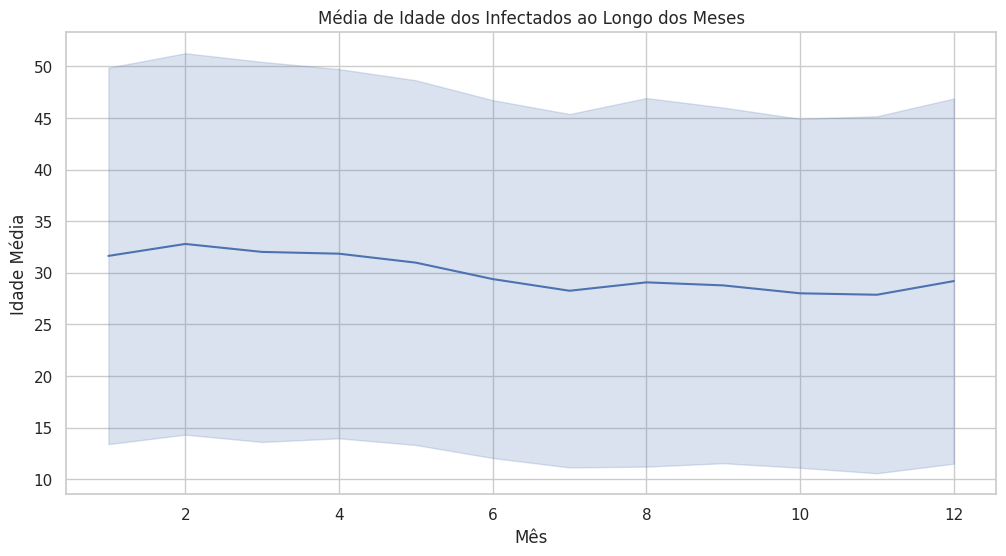

In [102]:
# Idade dos infectados vs. Estação do Ano
plt.figure(figsize=(12,6))
# Usando o mês como proxy para estação
sns.lineplot(data=df_mestre.reset_index(), x='month', y='idade', estimator='mean', errorbar='sd')
plt.title('Média de Idade dos Infectados ao Longo dos Meses')
plt.xlabel('Mês')
plt.ylabel('Idade Média')
plt.grid(True)
plt.show()

Porcentagem de pacientes com sintomas por faixa de umidade:
                   nausea    cefaleia
faixa_umidade                        
Muito Seco     152.173913  126.086957
Seco           162.190083  123.760331
Ideal          159.811687  118.335575
Úmido          158.146024  117.335078


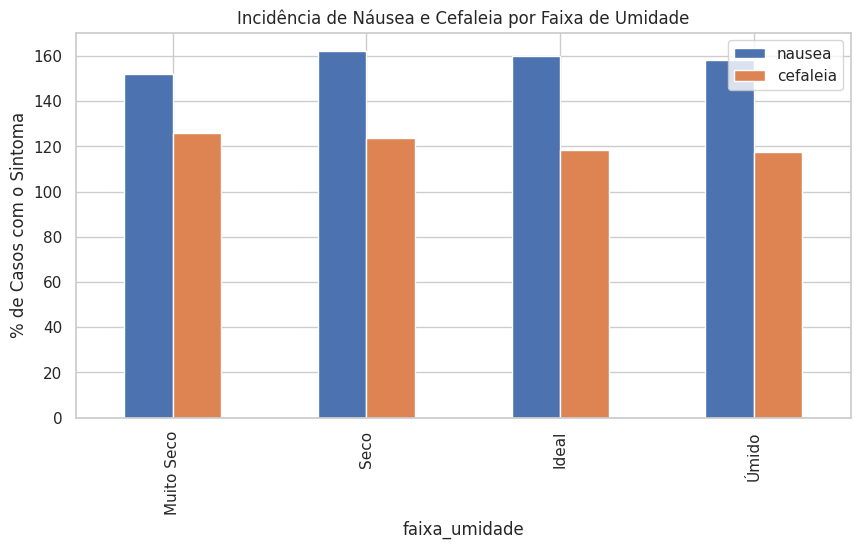

In [103]:
# Náusea/Cefaleia vs. Baixa Umidade
# incidência de sintomas específicos aumenta quando o ar está mais seco

# Criando faixas de umidade para facilitar a visualização
df_mestre['faixa_umidade'] = pd.cut(df_mestre['umidade_dia'], bins=[0, 40, 60, 80, 100],
                                    labels=['Muito Seco', 'Seco', 'Ideal', 'Úmido'])

analise_sintomas = df_mestre.reset_index().groupby('faixa_umidade', observed=True).agg({
    'nausea': 'mean',
    'cefaleia': 'mean'
}) * 100 # Para ver em porcentagem

print("Porcentagem de pacientes com sintomas por faixa de umidade:")
print(analise_sintomas)

analise_sintomas.plot(kind='bar', figsize=(10,5))
plt.ylabel('% de Casos com o Sintoma')
plt.title('Incidência de Náusea e Cefaleia por Faixa de Umidade')
plt.show()

<Axes: title={'center': 'Relação entre Temperatura Máxima e Gravidade dos Sintomas'}, xlabel='Temperatura Máxima (°C)', ylabel='Média do Score de Gravidade'>

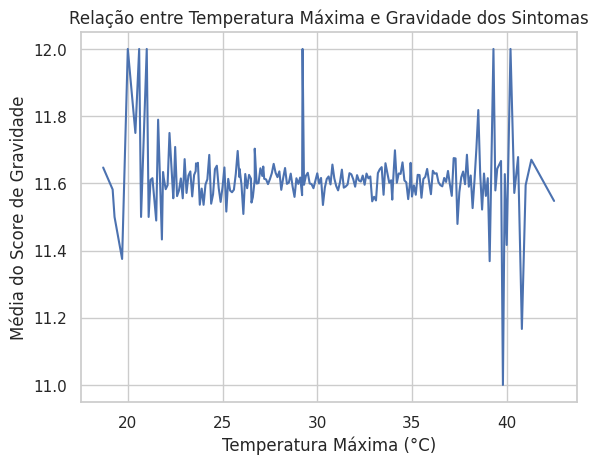

In [104]:
df_mestre.groupby('temp_max_dia')['score_gravidade'].mean().plot(
    title='Relação entre Temperatura Máxima e Gravidade dos Sintomas',
    ylabel='Média do Score de Gravidade',
    xlabel='Temperatura Máxima (°C)'
)

In [105]:
# Relação Sexo vs. Sintomas vs. Clima:
df_mestre.pivot_table(index='cs_sexo', values=['score_gravidade', 'temp_media_dia'], aggfunc='mean')

,score_gravidade,temp_media_dia
cs_sexo,,
F,11.592986,24.928801
M,11.625204,24.828267


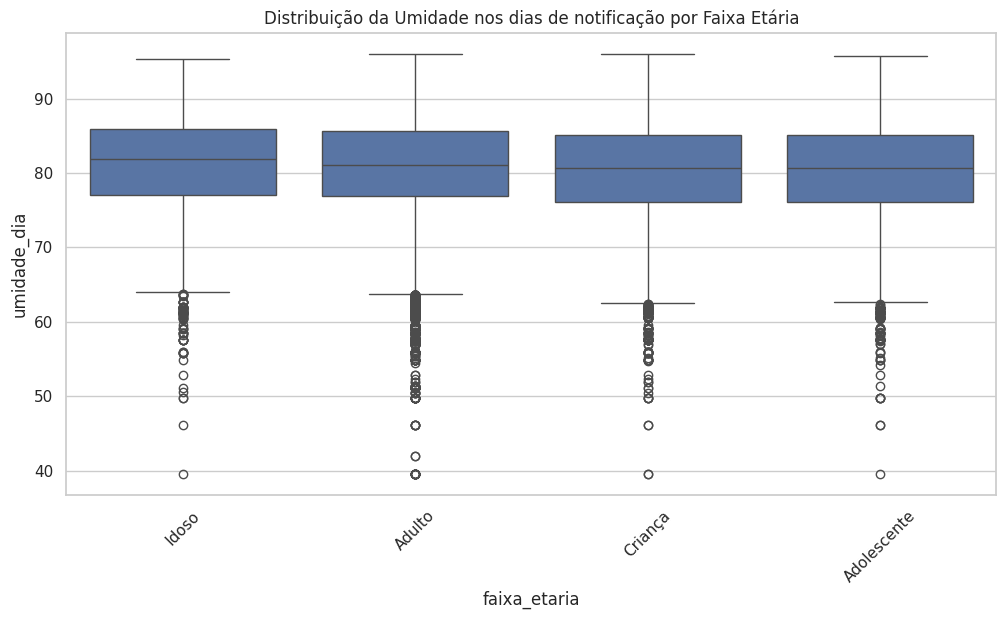

In [106]:
# Distribuição de Casos por Faixa Etária e Umidade:
# .reset_index() para que a 'Data' vire uma coluna normal e o índice seja numérico único (0, 1, 2...)
df_plot = df_mestre.reset_index()

plt.figure(figsize=(12,6))
sns.boxplot(data=df_plot, x='faixa_etaria', y='umidade_dia')

plt.title('Distribuição da Umidade nos dias de notificação por Faixa Etária')
plt.xticks(rotation=45) # Rotaciona as faixas etárias para não sobrepor
plt.show()

### Etapa 2: O "Dataframe de Séries Temporais" (Agregado por Dia)

In [107]:
# Agregação Diária: Transformando pacientes em contagens e médias
df_diario = df_mestre.groupby('Data').agg({
    'classificacao': 'count',      # Total de casos no dia
    'score_gravidade': 'mean',     # Gravidade média dos casos do dia
    'idade': 'mean',               # Idade média dos infectados
    'chuva_dia': 'first',          # Já está agregado, pegamos o valor do dia
    'temp_max_dia': 'first',
    'temp_min_dia': 'first',
    'umidade_dia': 'first',
    'year': 'first',
    'month': 'first',
    'day_week': 'first'
}).rename(columns={'classificacao': 'total_casos'})

In [108]:
# Garantir que a série temporal não tenha buracos (dias sem casos = 0)
idx = pd.date_range(df_diario.index.min(), df_diario.index.max())
df_diario = df_diario.reindex(idx)
df_diario['total_casos'] = df_diario['total_casos'].fillna(0)

# Para o clima, preenchemos pequenas falhas com interpolação
df_diario[['chuva_dia', 'temp_min_dia', 'temp_max_dia', 'umidade_dia']] = df_diario[['chuva_dia', 'temp_min_dia', 'temp_max_dia', 'umidade_dia']].interpolate()

In [109]:
# Criação de Lags (O clima do passado afetando o presente)
lags = [7, 15, 21, 30, 45, 50, 60]

for lag in lags:
    # Chuva acumulada nos últimos X dias (Soma móvel)
    df_diario[f'chuva_acum_{lag}d'] = df_diario['chuva_dia'].rolling(window=lag).sum()

    # Gravidade defasada (Para ver se a gravidade sobe antes dos casos)
    df_diario[f'gravidade_lag_{lag}d'] = df_diario['score_gravidade'].shift(lag)

In [110]:
# Cálculo de Médias Móveis (Suavização da curva de casos)
for lag in lags:
  df_diario[f'casos_mm{lag}d'] = df_diario['total_casos'].rolling(window=lag).mean()

In [111]:
# Correlação de Pearson (Qual lag é mais forte?)
# Isso responde: "A chuva de quantos dias atrás melhor explica os casos de hoje?"
correlacoes = df_diario[
    ['total_casos', 'chuva_acum_7d',
     'chuva_acum_15d','chuva_acum_21d',
     'chuva_acum_30d', 'chuva_acum_45d',
     'chuva_acum_50d', 'chuva_acum_60d']].corr()
print(correlacoes['total_casos'])

total_casos       1.000000
chuva_acum_7d    -0.004095
chuva_acum_15d   -0.010401
chuva_acum_21d   -0.002534
chuva_acum_30d    0.001590
chuva_acum_45d    0.061133
chuva_acum_50d    0.083975
chuva_acum_60d    0.123488
Name: total_casos, dtype: float64


In [112]:
# Verifique a correlação da Temperatura Mínima com lags
col_min = list()
for lag in lags:
  name = f'temp_min_lag_{lag}d'
  df_diario[name] = df_diario['temp_min_dia'].shift(lag)
  col_min.append(name)

In [113]:
cols_min = ['total_casos'] + col_min

In [114]:
df_diario[cols_min].corr()

,total_casos,temp_min_lag_7d,temp_min_lag_15d,temp_min_lag_21d,temp_min_lag_30d,temp_min_lag_45d,temp_min_lag_50d,temp_min_lag_60d
total_casos,1.000000,0.180900,0.182467,0.198762,0.209892,0.233197,0.244525,0.215397
temp_min_lag_7d,0.180900,1.000000,0.626036,0.627183,0.586109,0.495557,0.427754,0.331292
temp_min_lag_15d,0.182467,0.626036,1.000000,0.635156,0.629789,0.519132,0.502004,0.424168
temp_min_lag_21d,0.198762,0.627183,0.635156,1.000000,0.625162,0.573165,0.524604,0.477811
temp_min_lag_30d,0.209892,0.586109,0.629789,0.625162,1.000000,0.629089,0.617985,0.517711
temp_min_lag_45d,0.233197,0.495557,0.519132,0.573165,0.629089,1.000000,0.652566,0.628328
temp_min_lag_50d,0.244525,0.427754,0.502004,0.524604,0.617985,0.652566,1.000000,0.622709
temp_min_lag_60d,0.215397,0.331292,0.424168,0.477811,0.517711,0.628328,0.622709,1.000000


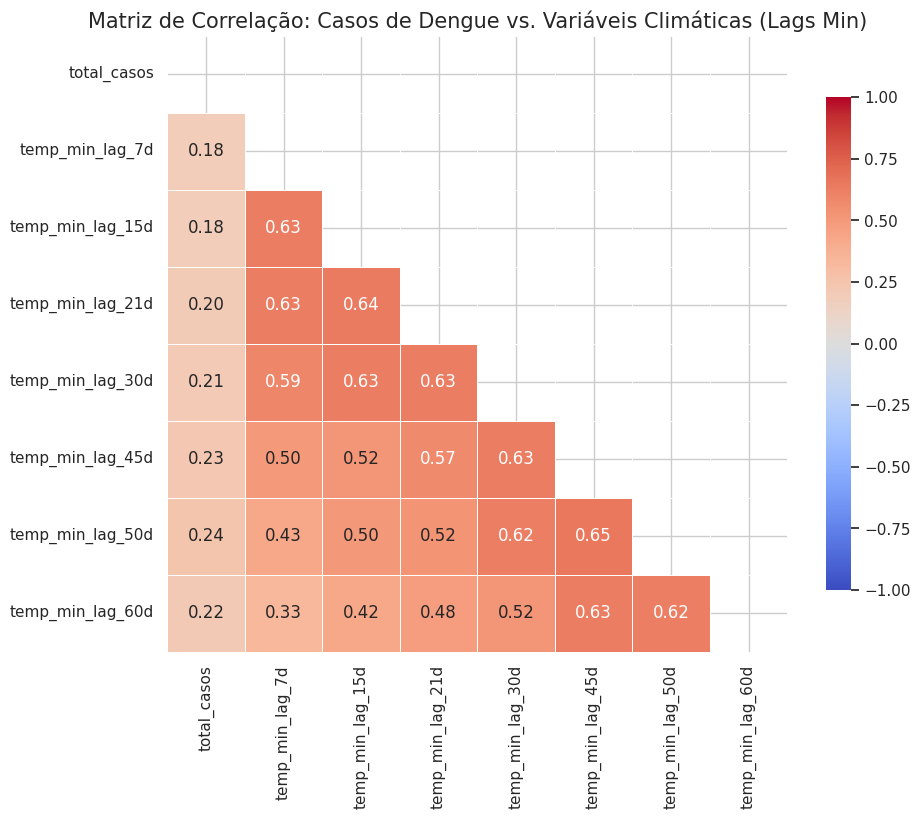

In [115]:
# A primeira coluna (total_casos): É aqui que você foca.
# Procure o quadrado "mais vermelho". Se a temp_min_lag_21d estiver mais escura que a chuva_acum_45d,
# seu modelo de previsão futuro deve priorizar a temperatura.

# Correlações entre variáveis (Multicolinearidade):
# Se a temp_min_lag_14d e a temp_min_lag_21d tiverem uma correlação muito alta entre si (ex: > 0.90),
# significa que elas trazem quase a mesma informação. Na hora de criar um modelo estatístico,
# provavelmente escolheria apenas uma delas para evitar redundância.

corr_matrix = df_diario[cols_min].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Configurando o plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Mostra os números dentro dos quadrados
    fmt=".2f",           # Duas casas decimais
    cmap='coolwarm',     # Azul para negativo, Vermelho para positivo
    vmin=-1, vmax=1,     # Escala padrão de correlação
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação: Casos de Dengue vs. Variáveis Climáticas (Lags Min)', fontsize=15)
plt.show()

In [116]:
# Verifique a correlação da Temperatura Máxima com lags
col_max = list()
for lag in lags:
  name = f'temp_max_lag_{lag}d'
  df_diario[name] = df_diario['temp_max_dia'].shift(lag)
  col_max.append(name)

cols_max = ['total_casos'] + col_max
cols_max

df_diario[cols_max].corr()

,total_casos,temp_max_lag_7d,temp_max_lag_15d,temp_max_lag_21d,temp_max_lag_30d,temp_max_lag_45d,temp_max_lag_50d,temp_max_lag_60d
total_casos,1.000000,0.092006,0.101188,0.118182,0.113997,0.161732,0.152869,0.135991
temp_max_lag_7d,0.092006,1.000000,0.218137,0.277955,0.222603,0.180390,0.186304,0.124828
temp_max_lag_15d,0.101188,0.218137,1.000000,0.250782,0.273806,0.185620,0.186984,0.168259
temp_max_lag_21d,0.118182,0.277955,0.250782,1.000000,0.225290,0.220495,0.153914,0.172472
temp_max_lag_30d,0.113997,0.222603,0.273806,0.225290,1.000000,0.275739,0.240572,0.185638
temp_max_lag_45d,0.161732,0.180390,0.185620,0.220495,0.275739,1.000000,0.274440,0.277622
temp_max_lag_50d,0.152869,0.186304,0.186984,0.153914,0.240572,0.274440,1.000000,0.252004
temp_max_lag_60d,0.135991,0.124828,0.168259,0.172472,0.185638,0.277622,0.252004,1.000000


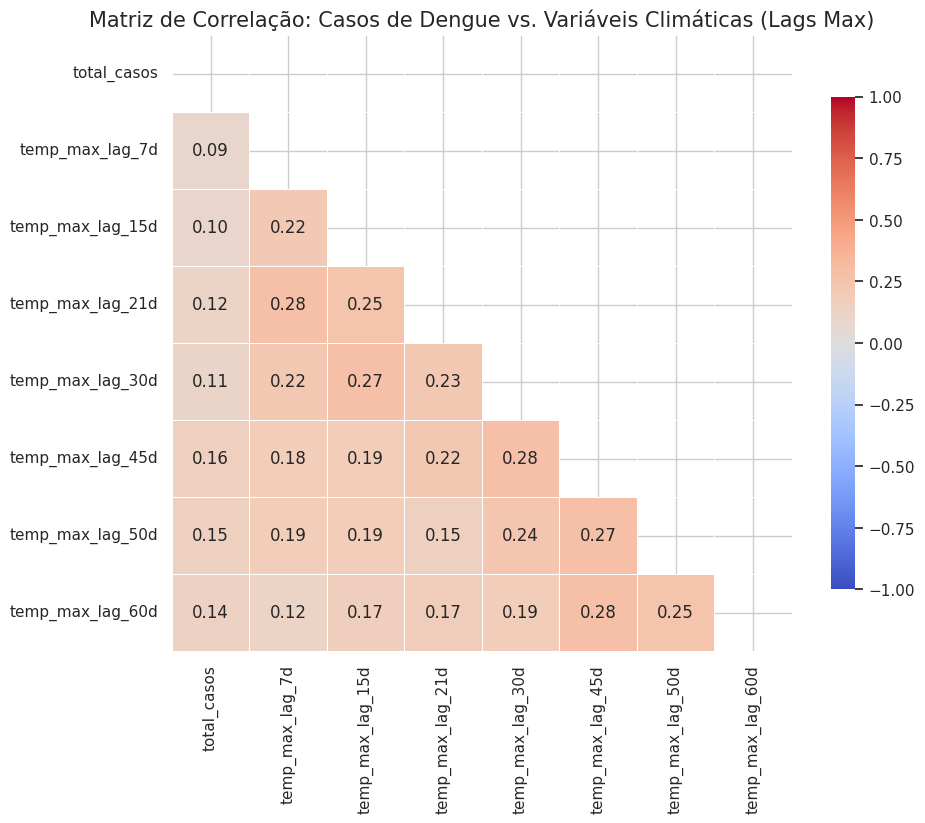

In [117]:
corr_matrix = df_diario[cols_max].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Configurando o plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Mostra os números dentro dos quadrados
    fmt=".2f",           # Duas casas decimais
    cmap='coolwarm',     # Azul para negativo, Vermelho para positivo
    vmin=-1, vmax=1,     # Escala padrão de correlação
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação: Casos de Dengue vs. Variáveis Climáticas (Lags Max)', fontsize=15)
plt.show()

In [118]:
lags

[7, 15, 21, 30, 45, 50, 60]

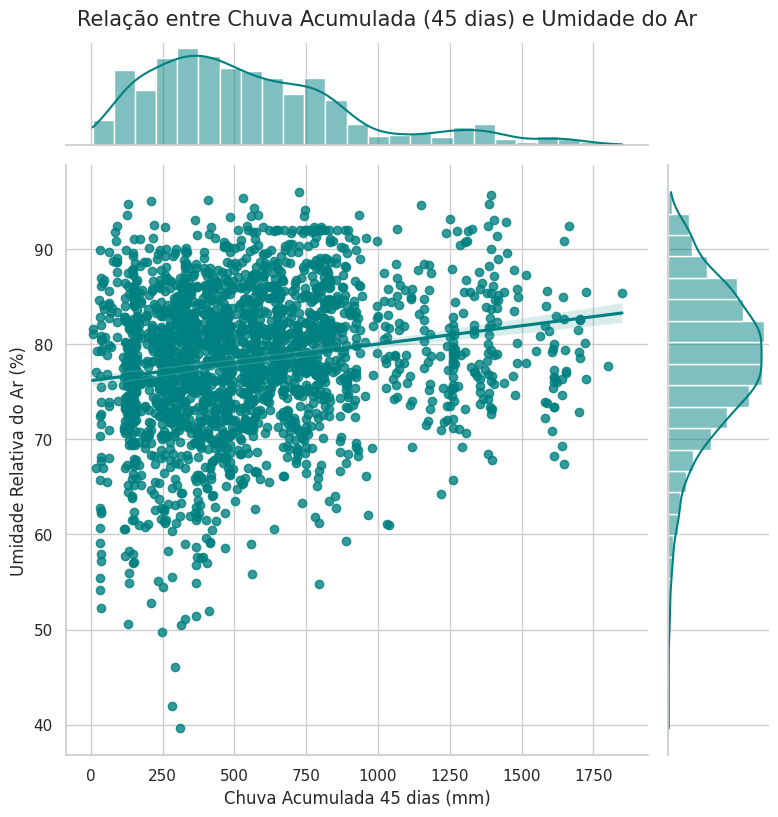

In [119]:
d = lags[4]
# Configurando o estilo
sns.set_theme(style="whitegrid")

# Criando o Joint Plot
# Ele vai mostrar a relação entre Chuva e Umidade Diária
g = sns.jointplot(
    data=df_diario,
    x=f'chuva_acum_{d}d',
    y='umidade_dia',
    kind="reg",         # Adiciona uma linha de regressão e KDE
    color="teal",
    marginal_kws=dict(bins=25, fill=True), # Configura os histogramas nas bordas
    height=8
)

# Ajustando títulos e eixos
g.fig.suptitle(f'Relação entre Chuva Acumulada ({d} dias) e Umidade do Ar', y=1.02, fontsize=15)
g.set_axis_labels(f'Chuva Acumulada {d} dias (mm)', 'Umidade Relativa do Ar (%)', fontsize=12)

plt.show()

/tmp/ipykernel_19415/3464465575.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_casos = df_diario.pivot_table(index='faixa_umidade', columns='faixa_chuva', values='total_casos', aggfunc='mean')


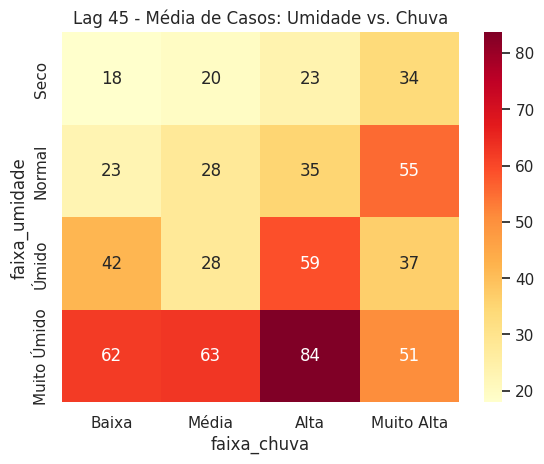

In [120]:
# Ver a média de casos cruzando Faixas de Umidade e Faixas de Chuva
df_diario['faixa_chuva'] = pd.qcut(df_diario[f'chuva_acum_{d}d'], q=4, labels=['Baixa', 'Média', 'Alta', 'Muito Alta'])
df_diario['faixa_umidade'] = pd.qcut(df_diario['umidade_dia'], q=4, labels=['Seco', 'Normal', 'Úmido', 'Muito Úmido'])

pivot_casos = df_diario.pivot_table(index='faixa_umidade', columns='faixa_chuva', values='total_casos', aggfunc='mean')
sns.heatmap(pivot_casos, annot=True, cmap='YlOrRd')
plt.title(f'Lag {d} - Média de Casos: Umidade vs. Chuva')
plt.show()

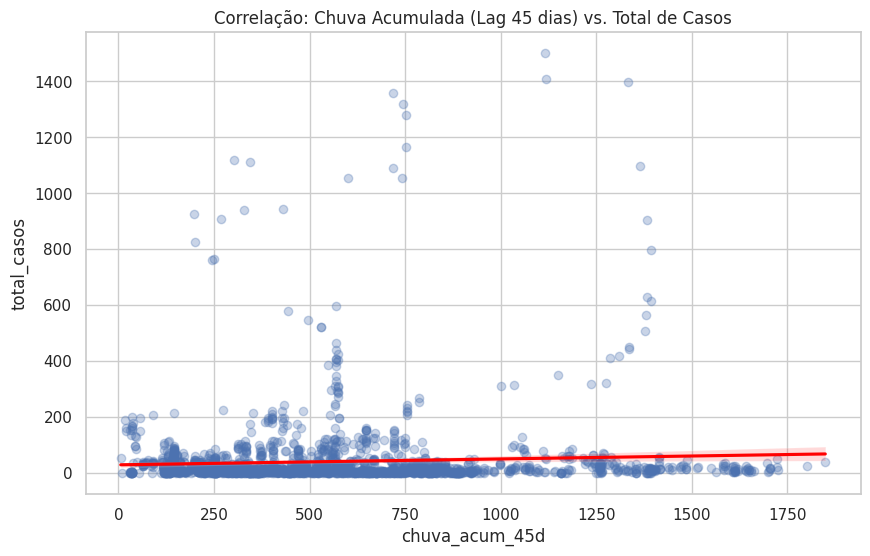

In [121]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_diario, x=f'chuva_acum_{d}d', y='total_casos',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Correlação: Chuva Acumulada (Lag {d} dias) vs. Total de Casos')
plt.show()

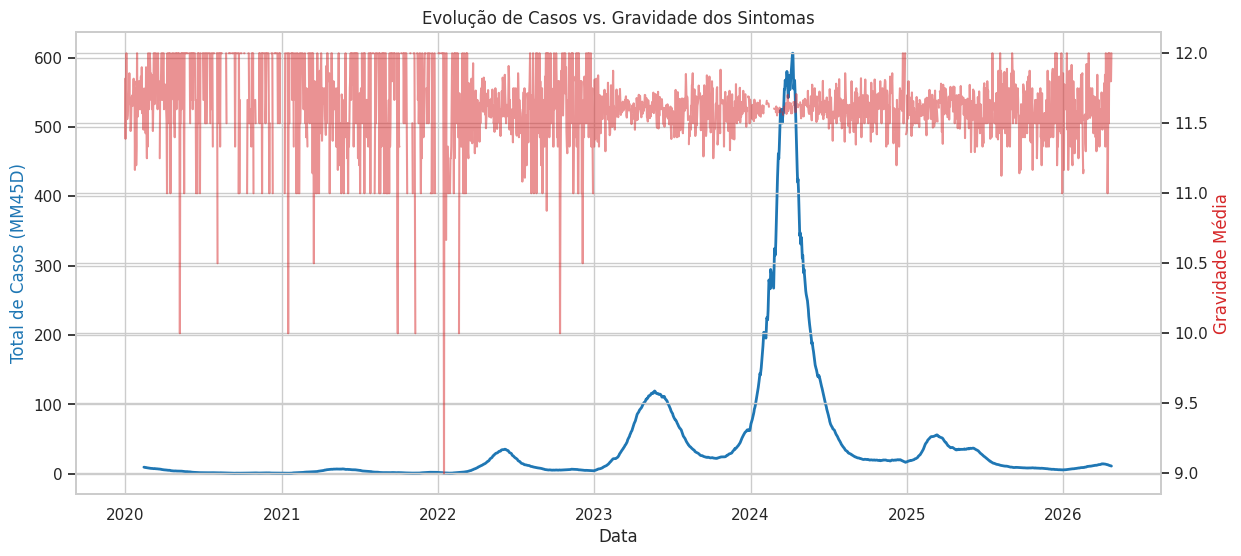

In [122]:
# Visualização de Tendência: Gravidade vs. Volume
# Será que os casos ficam mais graves antes do pico da epidemia?
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.set_xlabel('Data')
ax1.set_ylabel(f'Total de Casos (MM{d}D)', color='tab:blue')
ax1.plot(df_diario.index, df_diario[f'casos_mm{d}d'], color='tab:blue', linewidth=2)

ax2 = ax1.twinx()
ax2.set_ylabel('Gravidade Média', color='tab:red')
ax2.plot(df_diario.index, df_diario['score_gravidade'].rolling(1).mean(), color='tab:red', alpha=0.5)

plt.title('Evolução de Casos vs. Gravidade dos Sintomas')
plt.show()

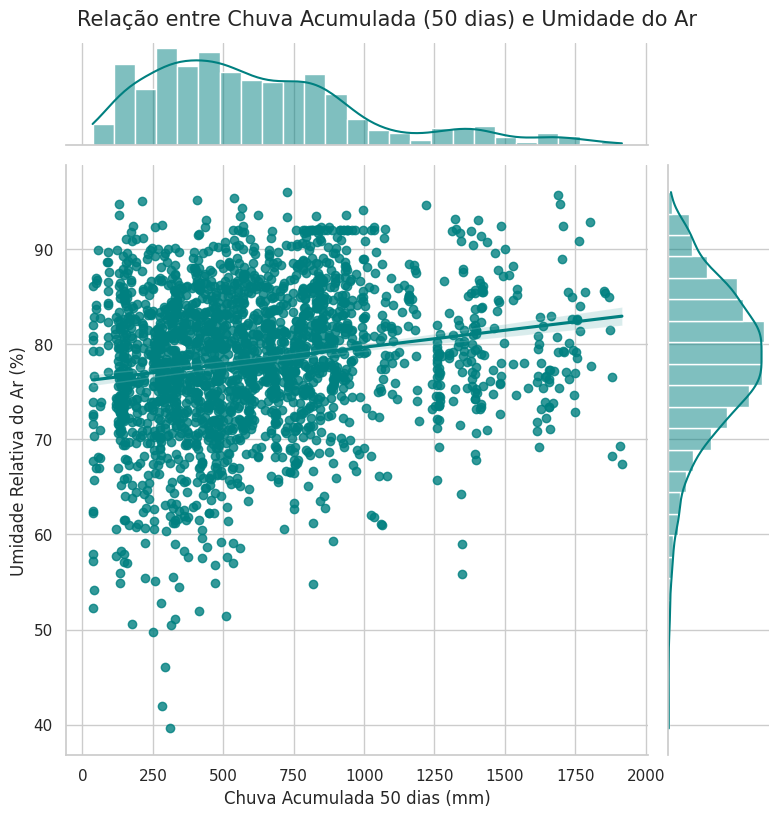

In [123]:
d = lags[5]
# Configurando o estilo
sns.set_theme(style="whitegrid")

# Criando o Joint Plot
# Ele vai mostrar a relação entre Chuva e Umidade Diária
g = sns.jointplot(
    data=df_diario,
    x=f'chuva_acum_{d}d',
    y='umidade_dia',
    kind="reg",         # Adiciona uma linha de regressão e KDE
    color="teal",
    marginal_kws=dict(bins=25, fill=True), # Configura os histogramas nas bordas
    height=8
)

# Ajustando títulos e eixos
g.fig.suptitle(f'Relação entre Chuva Acumulada ({d} dias) e Umidade do Ar', y=1.02, fontsize=15)
g.set_axis_labels(f'Chuva Acumulada {d} dias (mm)', 'Umidade Relativa do Ar (%)', fontsize=12)

plt.show()

/tmp/ipykernel_19415/3464465575.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_casos = df_diario.pivot_table(index='faixa_umidade', columns='faixa_chuva', values='total_casos', aggfunc='mean')


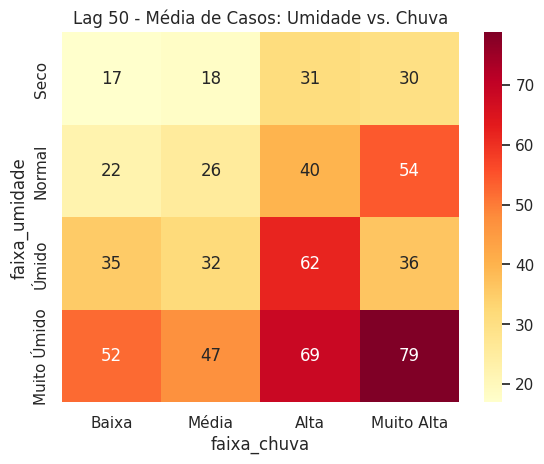

In [124]:
# Ver a média de casos cruzando Faixas de Umidade e Faixas de Chuva
df_diario['faixa_chuva'] = pd.qcut(df_diario[f'chuva_acum_{d}d'], q=4, labels=['Baixa', 'Média', 'Alta', 'Muito Alta'])
df_diario['faixa_umidade'] = pd.qcut(df_diario['umidade_dia'], q=4, labels=['Seco', 'Normal', 'Úmido', 'Muito Úmido'])

pivot_casos = df_diario.pivot_table(index='faixa_umidade', columns='faixa_chuva', values='total_casos', aggfunc='mean')
sns.heatmap(pivot_casos, annot=True, cmap='YlOrRd')
plt.title(f'Lag {d} - Média de Casos: Umidade vs. Chuva')
plt.show()

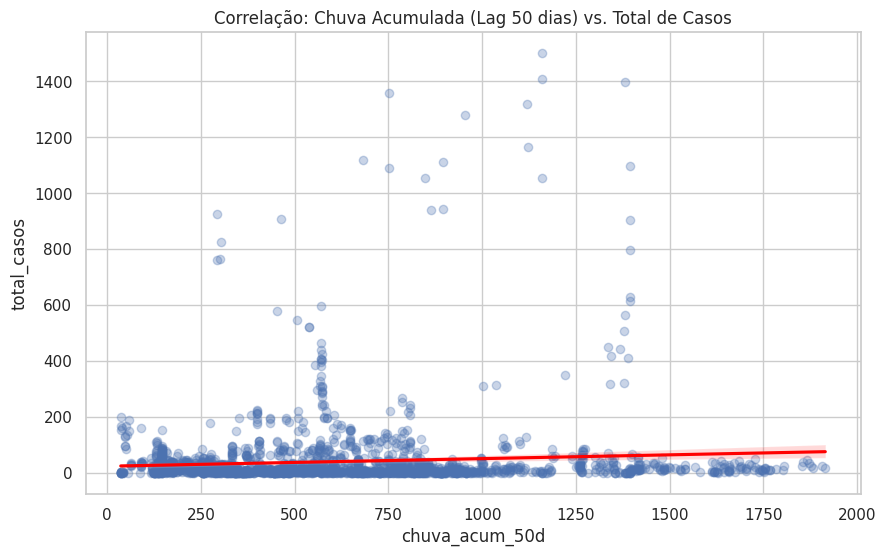

In [125]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_diario, x=f'chuva_acum_{d}d', y='total_casos',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Correlação: Chuva Acumulada (Lag {d} dias) vs. Total de Casos')
plt.show()

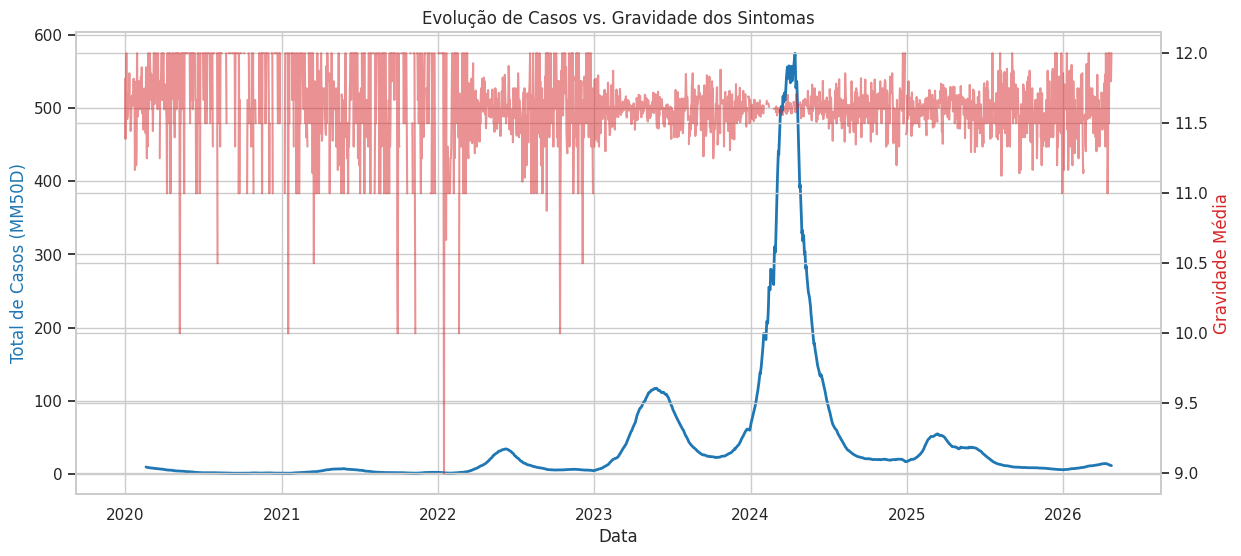

In [126]:
# Visualização de Tendência: Gravidade vs. Volume
# Será que os casos ficam mais graves antes do pico da epidemia?
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.set_xlabel('Data')
ax1.set_ylabel(f'Total de Casos (MM{d}D)', color='tab:blue')
ax1.plot(df_diario.index, df_diario[f'casos_mm{d}d'], color='tab:blue', linewidth=2)

ax2 = ax1.twinx()
ax2.set_ylabel('Gravidade Média', color='tab:red')
ax2.plot(df_diario.index, df_diario['score_gravidade'].rolling(1).mean(), color='tab:red', alpha=0.5)

plt.title('Evolução de Casos vs. Gravidade dos Sintomas')
plt.show()

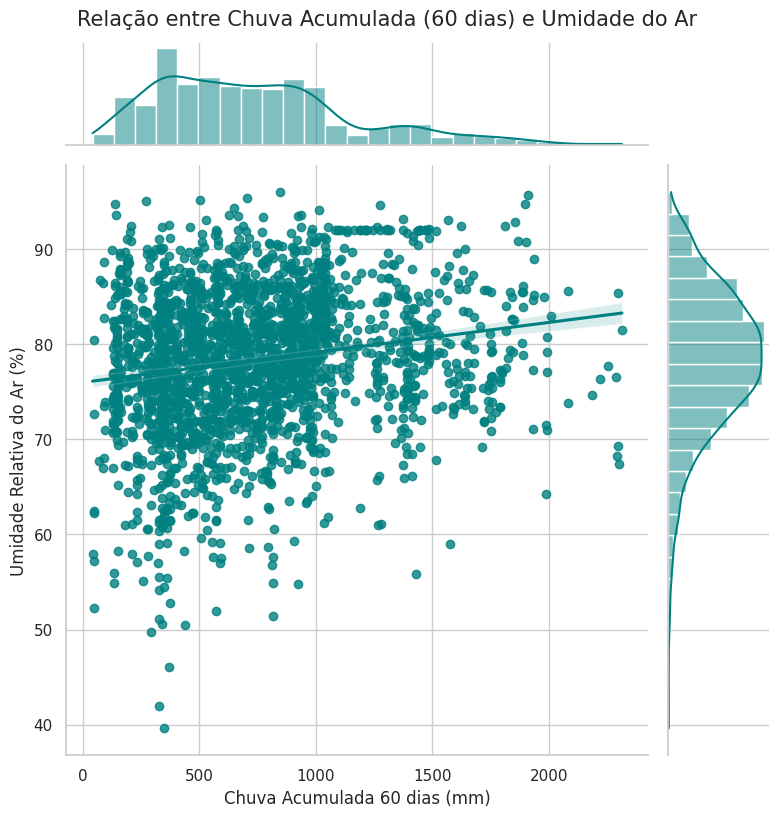

In [127]:
d = lags[6]
# Configurando o estilo
sns.set_theme(style="whitegrid")

# Criando o Joint Plot
# Ele vai mostrar a relação entre Chuva e Umidade Diária
g = sns.jointplot(
    data=df_diario,
    x=f'chuva_acum_{d}d',
    y='umidade_dia',
    kind="reg",         # Adiciona uma linha de regressão e KDE
    color="teal",
    marginal_kws=dict(bins=25, fill=True), # Configura os histogramas nas bordas
    height=8
)

# Ajustando títulos e eixos
g.fig.suptitle(f'Relação entre Chuva Acumulada ({d} dias) e Umidade do Ar', y=1.02, fontsize=15)
g.set_axis_labels(f'Chuva Acumulada {d} dias (mm)', 'Umidade Relativa do Ar (%)', fontsize=12)

plt.show()

/tmp/ipykernel_19415/3464465575.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_casos = df_diario.pivot_table(index='faixa_umidade', columns='faixa_chuva', values='total_casos', aggfunc='mean')


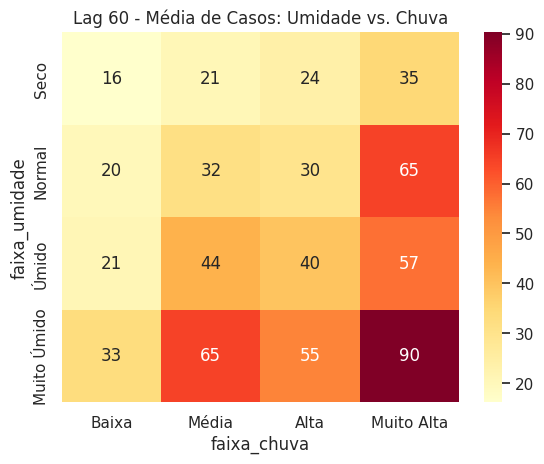

In [128]:
# Ver a média de casos cruzando Faixas de Umidade e Faixas de Chuva
df_diario['faixa_chuva'] = pd.qcut(df_diario[f'chuva_acum_{d}d'], q=4, labels=['Baixa', 'Média', 'Alta', 'Muito Alta'])
df_diario['faixa_umidade'] = pd.qcut(df_diario['umidade_dia'], q=4, labels=['Seco', 'Normal', 'Úmido', 'Muito Úmido'])

pivot_casos = df_diario.pivot_table(index='faixa_umidade', columns='faixa_chuva', values='total_casos', aggfunc='mean')
sns.heatmap(pivot_casos, annot=True, cmap='YlOrRd')
plt.title(f'Lag {d} - Média de Casos: Umidade vs. Chuva')
plt.show()

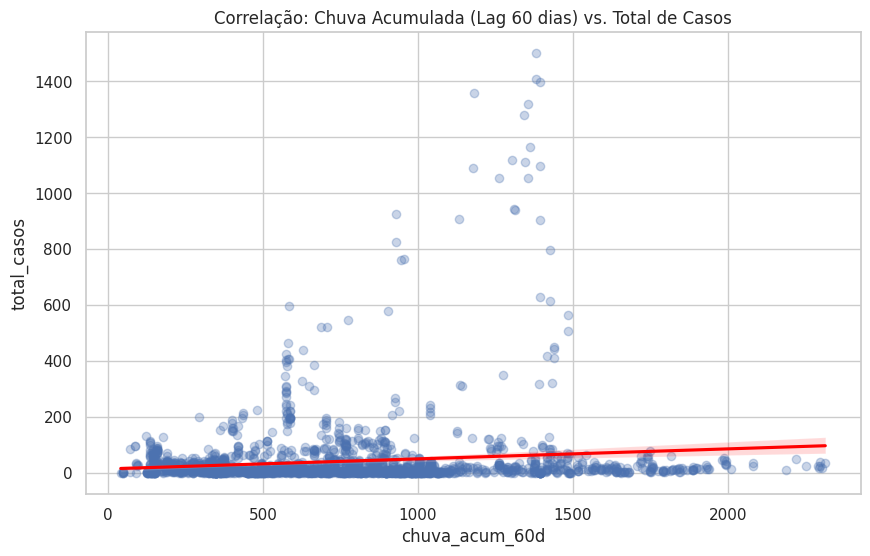

In [129]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_diario, x=f'chuva_acum_{d}d', y='total_casos',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Correlação: Chuva Acumulada (Lag {d} dias) vs. Total de Casos')
plt.show()

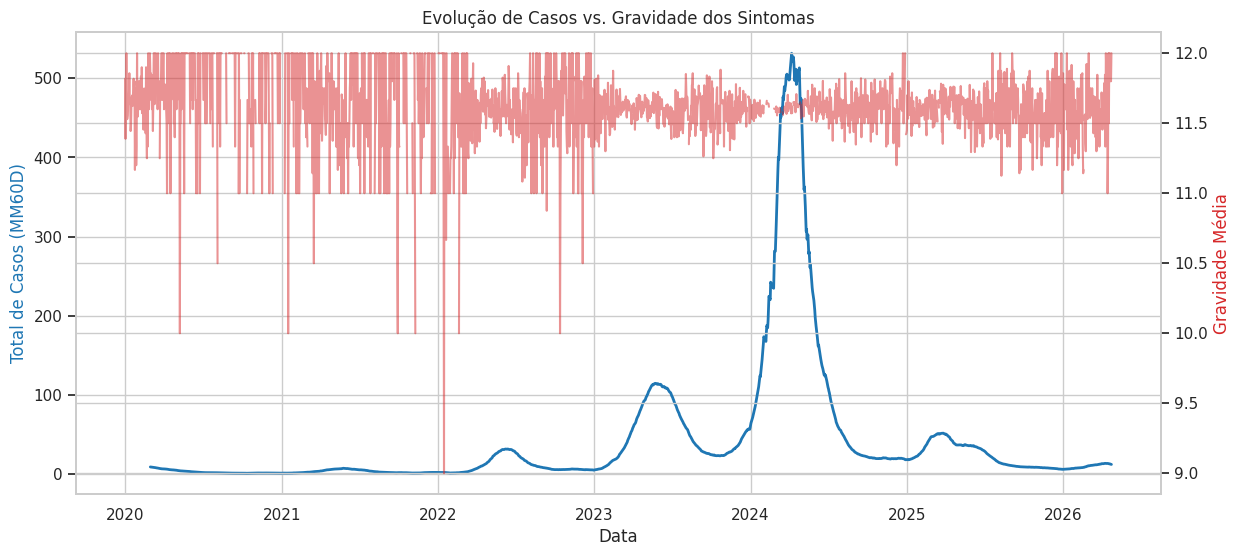

In [130]:
# Visualização de Tendência: Gravidade vs. Volume
# Será que os casos ficam mais graves antes do pico da epidemia?
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.set_xlabel('Data')
ax1.set_ylabel(f'Total de Casos (MM{d}D)', color='tab:blue')
ax1.plot(df_diario.index, df_diario[f'casos_mm{d}d'], color='tab:blue', linewidth=2)

ax2 = ax1.twinx()
ax2.set_ylabel('Gravidade Média', color='tab:red')
ax2.plot(df_diario.index, df_diario['score_gravidade'].rolling(1).mean(), color='tab:red', alpha=0.5)

plt.title('Evolução de Casos vs. Gravidade dos Sintomas')
plt.show()

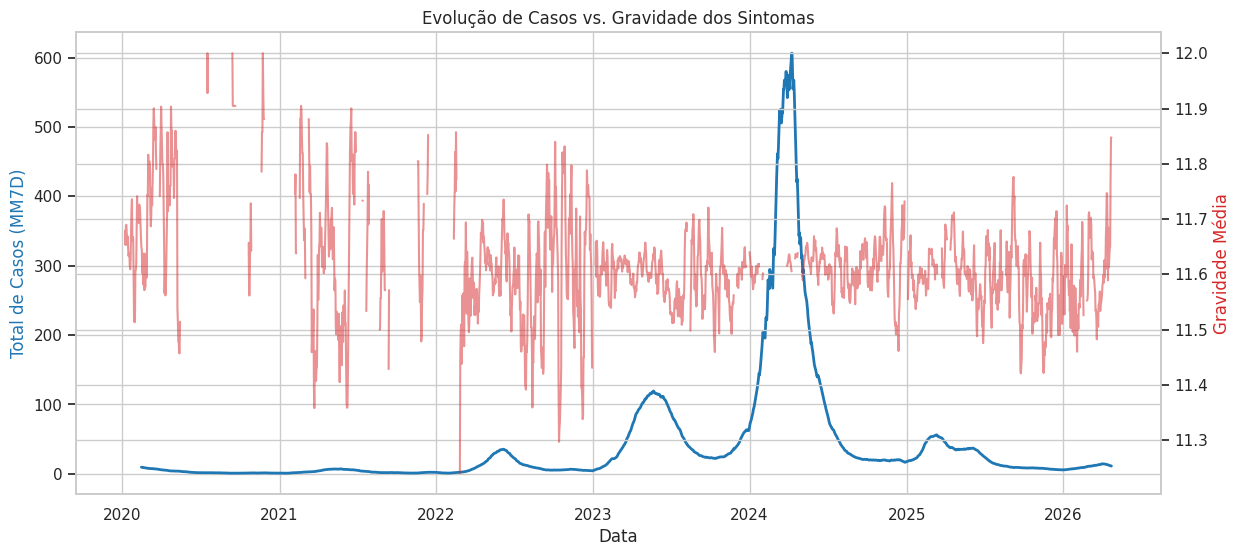

In [131]:
# Visualização de Tendência: Gravidade vs. Volume
# Será que os casos ficam mais graves antes do pico da epidemia?
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.set_xlabel('Data')
ax1.set_ylabel('Total de Casos (MM7D)', color='tab:blue')
ax1.plot(df_diario.index, df_diario['casos_mm45d'], color='tab:blue', linewidth=2)

ax2 = ax1.twinx()
ax2.set_ylabel('Gravidade Média', color='tab:red')
ax2.plot(df_diario.index, df_diario['score_gravidade'].rolling(7).mean(), color='tab:red', alpha=0.5)

plt.title('Evolução de Casos vs. Gravidade dos Sintomas')
plt.show()

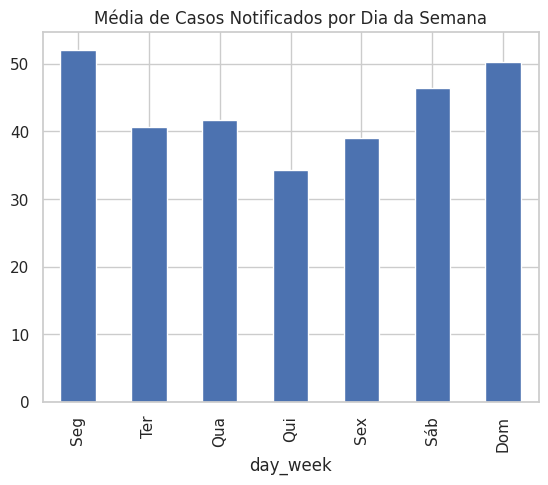

In [132]:
# Sazonalidade (Dia da Semana)
# Isso ajuda a identificar o "efeito notificação":
df_diario.groupby('day_week')['total_casos'].mean().plot(kind='bar')
plt.title('Média de Casos Notificados por Dia da Semana')
plt.xticks(range(7), ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
plt.show()

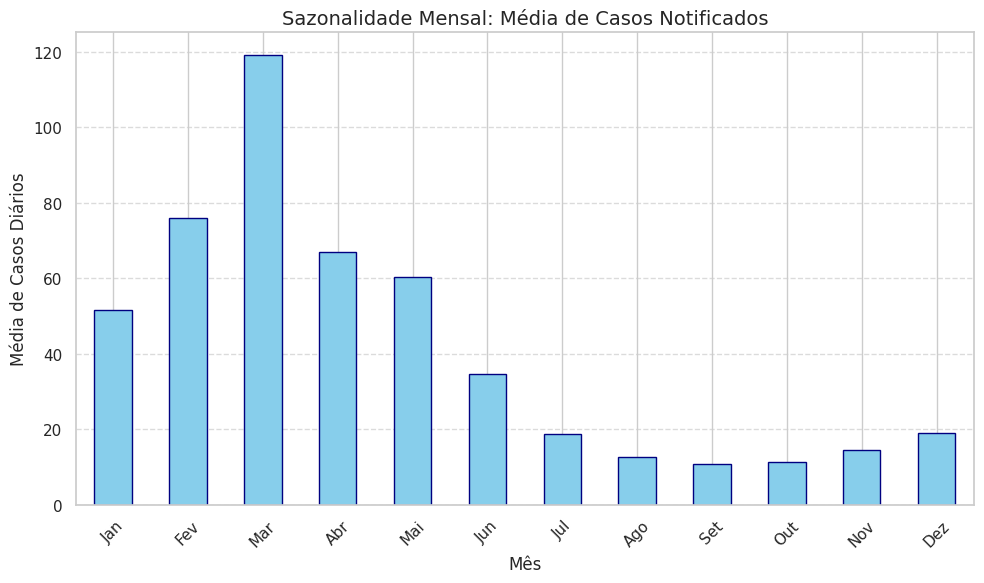

In [133]:
# 1. Agrupando por mês e calculando a média de casos
# Usamos .mean() para saber o comportamento médio de cada mês ao longo dos anos
sazonalidade_mensal = df_diario.groupby('month')['total_casos'].mean()

# 2. Plotando o gráfico de barras
plt.figure(figsize=(10, 6))
sazonalidade_mensal.plot(kind='bar', color='skyblue', edgecolor='navy')

# 3. Ajustes estéticos
plt.title('Sazonalidade Mensal: Média de Casos Notificados', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Média de Casos Diários')

# Definindo os nomes dos meses no eixo X
plt.xticks(
    range(0, 12),
    ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'],
    rotation=45
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [134]:
df_diario.isna().sum().sum(), df_diario.shape, df_diario.columns

(np.int64(3261),
 (2305, 47),
 Index(['total_casos', 'score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia',
        'temp_min_dia', 'umidade_dia', 'year', 'month', 'day_week',
        'chuva_acum_7d', 'gravidade_lag_7d', 'chuva_acum_15d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'gravidade_lag_21d',
        'chuva_acum_30d', 'gravidade_lag_30d', 'chuva_acum_45d',
        'gravidade_lag_45d', 'chuva_acum_50d', 'gravidade_lag_50d',
        'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d',
        'casos_mm21d', 'casos_mm30d', 'casos_mm45d', 'casos_mm50d',
        'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_50d', 'temp_max_lag_60d',
        'faixa_chuva', 'faixa_umidade'],
       dtype='object'))

### Tratando dados

In [135]:
# Objetivo, Use este DataFrame, Exemplo de Pergunta
# Perfil Clínico, df_mestre, """Pessoas com diabetes têm maior score de gravidade?"""
# Previsão/Tendência, df_diario, """A chuva de 45 dias atrás preve o aumento de casos hoje?"""
# Impacto Climático, df_mestre, """A náusea é mais comum em dias de baixa umidade?"""
# Sazonalidade, df_diario, """Qual o mês com maior média de casos nos últimos 5 anos?"""

In [136]:
# Previsão/Tendência, df_diario, """A chuva de 45 dias atrás preve o aumento de casos hoje?"""

In [137]:
# Transformando a coluna de dados:
df_diario['year'] = df_diario.index.year
df_diario['month'] = df_diario.index.month
df_diario['day_week'] = df_diario.index.day_of_week
df_diario['day_month'] = df_diario.index.day
df_diario['day_month_start'] = df_diario.index.is_month_start.astype(int)
df_diario['day_month_end'] = df_diario.index.is_month_end.astype(int)
df_diario['day_quarter_start'] = df_diario.index.is_quarter_start.astype(int)
df_diario['day_quarter_end'] = df_diario.index.is_quarter_end.astype(int)
df_diario['day_year_start'] = df_diario.index.is_year_start.astype(int)
df_diario['day_year_end'] = df_diario.index.is_year_end.astype(int)

df_diario[['year','month','day_week','day_month','day_month_start','day_month_end','day_quarter_start','day_quarter_end','day_year_start','day_year_end']]

,year,month,day_week,day_month,day_month_start,day_month_end,day_quarter_start,day_quarter_end,day_year_start,day_year_end
2020-01-01,2020,1,2,1,1,0,1,0,1,0
2020-01-02,2020,1,3,2,0,0,0,0,0,0
2020-01-03,2020,1,4,3,0,0,0,0,0,0
2020-01-04,2020,1,5,4,0,0,0,0,0,0
2020-01-05,2020,1,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
2026-04-19,2026,4,6,19,0,0,0,0,0,0
2026-04-20,2026,4,0,20,0,0,0,0,0,0
2026-04-21,2026,4,1,21,0,0,0,0,0,0
2026-04-22,2026,4,2,22,0,0,0,0,0,0


In [138]:
df_final = df_diario.copy()

In [139]:
df_final.index

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10',
               ...
               '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
               '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
               '2026-04-22', '2026-04-23'],
              dtype='datetime64[ns]', length=2305, freq='D')

In [140]:
# Preencher os dias sem pacientes (Idade e Gravidade)
# Usamos 'ffill' (forward fill) para dizer que a gravidade de um dia sem casos
# é similar à do último dia que teve casos.
df_final['score_gravidade'] = df_final['score_gravidade'].ffill().bfill()
df_final['idade'] = df_final['idade'].ffill().bfill()

In [141]:
# Recalcular os Lags de Gravidade (agora sem os nulos internos)
for lag in lags:
    df_final[f'gravidade_lag_{lag}d'] = df_final['score_gravidade'].shift(lag)

In [142]:
# Tratar o Clima (caso haja algum nulo perdido)
# Clima: Interpolação (preenche buracos no meio dos dados)
cols_clima = ['temp_max_dia', 'temp_min_dia', 'umidade_dia', 'chuva_dia']

# df_final[cols_clima] = df_final[cols_clima].interpolate(method='linear', limit_direction='both')
# Não causa data leakage
df_final[cols_clima] = df_final[cols_clima].interpolate(method='linear', limit_direction='forward')

In [143]:
# Casos e Médias Móveis de casos: Preenche com 0
cols_casos = [c for c in df_final.columns if 'casos' in c or 'total' in c]
df_final[cols_casos] = df_final[cols_casos].fillna(0)

In [144]:
df_final.isna().sum().sum()

np.int64(964)

In [145]:
print(df_final.isna().sum().sort_values(ascending=False).head(10))

temp_min_lag_60d     60
gravidade_lag_60d    60
temp_max_lag_60d     60
chuva_acum_60d       59
faixa_chuva          59
gravidade_lag_50d    50
temp_max_lag_50d     50
temp_min_lag_50d     50
chuva_acum_50d       49
temp_min_lag_45d     45
dtype: int64


In [146]:
# Lags: Remove as linhas iniciais que ficaram vazias
# Isso limpa os NaNs que o cálculo de 30d, 45d e 60d gerou inevitavelmente
# tem 2.305 dias (quase 6 anos), perder 60 dias do início não afetará a análise de sazonalidade
# df_diario_final = df.dropna()
df_diario_final = df_final.iloc[lags[-1]:]

print(df_diario_final.isna().sum().sort_values(ascending=False).head(10))

total_casos        0
score_gravidade    0
idade              0
chuva_dia          0
temp_max_dia       0
temp_min_dia       0
umidade_dia        0
year               0
month              0
day_week           0
dtype: int64


In [147]:
print(f"Dados originais: {df_final.shape[0]} dias")
print(f"Dados após limpar lags iniciais: {df_diario_final.shape[0]} dias")

Dados originais: 2305 dias
Dados após limpar lags iniciais: 2245 dias


## Fourier

In [148]:
def fourier_features(df, columns, periods, n_terms_list):
    t = np.arange(len(df))

    for col in columns:
        for period, n_terms in zip(periods, n_terms_list):
            period = int(period)  # ← garante que não vira array/lista

            for k in range(1, n_terms + 1):
                df[f"{col}_fourier_cos_p{period}_k{k}"] = np.cos(2 * np.pi * k * t / period)
                df[f"{col}_fourier_sin_p{period}_k{k}"] = np.sin(2 * np.pi * k * t / period)

    return df

In [149]:
seasonal_periods = [7, 30.44, 365.25]  # Semanal, Mensal e Anual
n_terms_list = [3, 1, 2] # Complexidade de cada onda

In [150]:
df_diario_final = fourier_features(df_diario_final, ['ciclos'], seasonal_periods, n_terms_list)

/tmp/ipykernel_19415/2231345146.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_fourier_cos_p{period}_k{k}"] = np.cos(2 * np.pi * k * t / period)
/tmp/ipykernel_19415/2231345146.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_fourier_sin_p{period}_k{k}"] = np.sin(2 * np.pi * k * t / period)
/tmp/ipykernel_19415/2231345146.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [156]:
fourier = df_diario_final.filter(like='ciclo')
cols_fourier = fourier.columns.to_list()
cols_fourier

['ciclos_fourier_cos_p7_k1',
 'ciclos_fourier_sin_p7_k1',
 'ciclos_fourier_cos_p7_k2',
 'ciclos_fourier_sin_p7_k2',
 'ciclos_fourier_cos_p7_k3',
 'ciclos_fourier_sin_p7_k3',
 'ciclos_fourier_cos_p30_k1',
 'ciclos_fourier_sin_p30_k1',
 'ciclos_fourier_cos_p365_k1',
 'ciclos_fourier_sin_p365_k1',
 'ciclos_fourier_cos_p365_k2',
 'ciclos_fourier_sin_p365_k2']

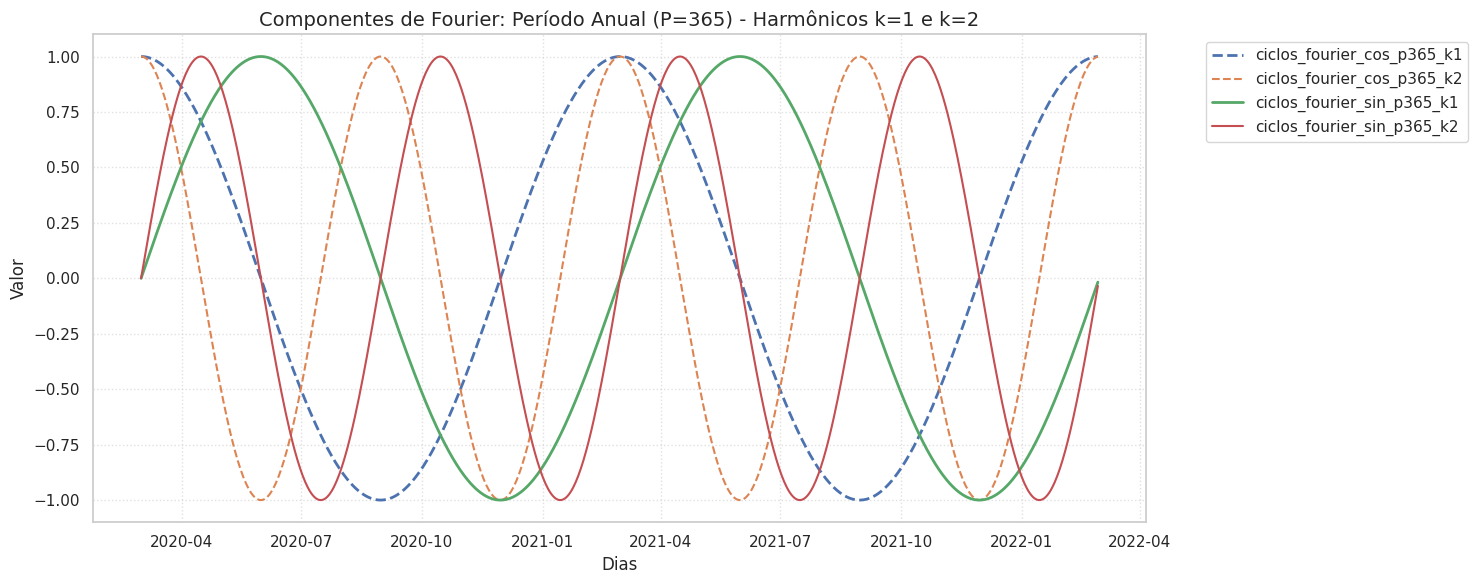

In [160]:
# Filtrando todas as colunas do período 365 (k1 e k2)
cols_365 = [c for c in df_diario_final.columns if "_p365_" in c]

# Criando o plot
fig, ax = plt.subplots(figsize=(15, 6))

# Plotando os primeiros 2 anos (730 dias)
for col in sorted(cols_365):
    # k1 terá amplitude total, k2 terá frequência dobrada
    linewidth = 2 if "k1" in col else 1.5
    linestyle = "-" if "sin" in col else "--"
    ax.plot(df_diario_final.index[:730], df_diario_final[col][:730],
            label=col, lw=linewidth, ls=linestyle)

ax.set_title("Componentes de Fourier: Período Anual (P=365) - Harmônicos k=1 e k=2", fontsize=14)
ax.set_xlabel("Dias")
ax.set_ylabel("Valor")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda fora do gráfico para clareza
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

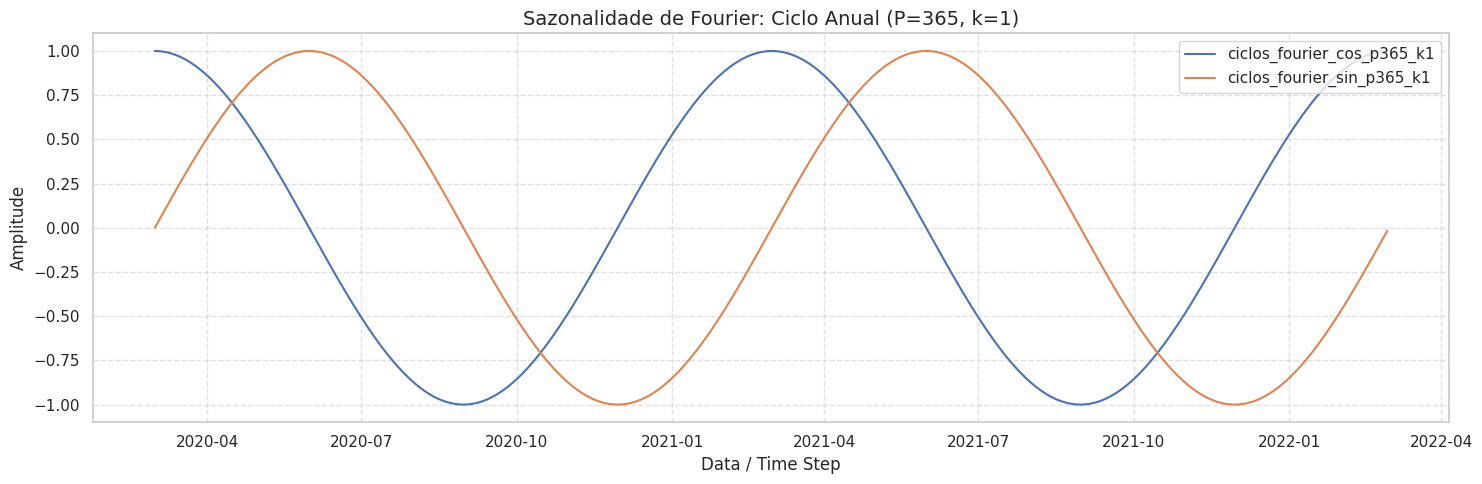

In [161]:
# Selecionando as colunas do primeiro harmônico (k=1) para o período 365
cols_p365 = [c for c in df_diario_final.columns if "p365" in c and "k1" in c]

plt.figure(figsize=(15, 5))

# Plotando os primeiros 730 dias (2 anos) para ver a ciclicidade
for col in cols_p365:
    plt.plot(df_diario_final.index[:730], df_diario_final[col][:730], label=col)

plt.title("Sazonalidade de Fourier: Ciclo Anual (P=365, k=1)", fontsize=14)
plt.xlabel("Data / Time Step")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [163]:
print(df_diario_final.isna().sum().sort_values(ascending=False).head(10))

total_casos        0
score_gravidade    0
idade              0
chuva_dia          0
temp_max_dia       0
temp_min_dia       0
umidade_dia        0
year               0
month              0
day_week           0
dtype: int64


## Salvando dataset

In [162]:
df_diario_final.shape, df_diario_final.columns

((2245, 66),
 Index(['total_casos', 'score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia',
        'temp_min_dia', 'umidade_dia', 'year', 'month', 'day_week',
        'chuva_acum_7d', 'gravidade_lag_7d', 'chuva_acum_15d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'gravidade_lag_21d',
        'chuva_acum_30d', 'gravidade_lag_30d', 'chuva_acum_45d',
        'gravidade_lag_45d', 'chuva_acum_50d', 'gravidade_lag_50d',
        'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d',
        'casos_mm21d', 'casos_mm30d', 'casos_mm45d', 'casos_mm50d',
        'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_50d', 'temp_max_lag_60d',
        'faixa_chuva', 'faixa_umidade', 'day_month', 'day_month_start',
        'day_month_end', '

In [164]:
df_diario_final = df_diario_final.rename_axis('data')

In [165]:
df_diario_final.index

DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
               '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
               '2020-03-09', '2020-03-10',
               ...
               '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
               '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
               '2026-04-22', '2026-04-23'],
              dtype='datetime64[ns]', name='data', length=2245, freq='D')

In [166]:
path_feat = '/content/drive/MyDrive/ML-UFF/df_feat.csv'
save_data_frame(df_diario_final, path_feat)